
# 📊 Análisis Supervisado – Alerta Ciudadana (MySQL)

**Base de datos**: `bd_alertaciudadana`  
**Tabla principal**: `incidentes` (con join a `categorias`)  
**Objetivo de clasificación (target)**: `estado`  
**Features considerados**: `titulo`, `descripcion`, `latitud`, `longitud`, `categoria`

---


## 1) Configuración e Imports

In [38]:

SEED = 42

import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display as show
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

import sqlalchemy as sa

print("✅ Librerías cargadas")

✅ Librerías cargadas


## 2) Parámetros de conexión y consulta

In [22]:
# ==============================
# 🔧 Parámetros de Conexión MySQL
# ==============================

MYSQL_USER = os.getenv('MYSQL_USER', 'root')
MYSQL_PASS = os.getenv('MYSQL_PASS', '1234')
MYSQL_HOST = os.getenv('MYSQL_HOST', 'localhost')
MYSQL_PORT = os.getenv('MYSQL_PORT', '3309')
MYSQL_DB   = os.getenv('MYSQL_DB', 'bd_alertaciudadana')

# ==============================
# 📋 Query adaptada
# ==============================
QUERY = """
SELECT i.id, i.titulo, i.descripcion, i.latitud, i.longitud, 
       i.estado, c.nombre AS categoria
FROM incidentes i
JOIN categorias c ON i.categoria_id = c.id;
"""

TARGET_COL = 'estado'
DROP_COLS = ['id']

# ==============================
# 🎨 Diseño de salida
# ==============================
print("\033[95m" + "="*50 + "\033[0m")
print(" 🚀  Parámetros listos para conexión a MySQL")
print("\033[95m" + "="*50 + "\033[0m")
print(f"👤 Usuario:     {MYSQL_USER}")
print(f"🔑 Password:    {'*' * len(MYSQL_PASS)}")
print(f"🖥️  Host:       {MYSQL_HOST}")
print(f"🔌 Puerto:     {MYSQL_PORT}")
print(f"🗄️  Base de datos: {MYSQL_DB}")
print(f"🎯 Target:      {TARGET_COL}")
print(f"🗑️  Drop Cols:  {DROP_COLS}")
print("\033[95m" + "="*50 + "\033[0m")


 🚀  Parámetros listos para conexión a MySQL
👤 Usuario:     root
🔑 Password:    ****
🖥️  Host:       localhost
🔌 Puerto:     3309
🗄️  Base de datos: bd_alertaciudadana
🎯 Target:      estado
🗑️  Drop Cols:  ['id']


## 3) Carga de Datos desde MySQL

In [23]:
from sqlalchemy.exc import SQLAlchemyError

print("\033[94m" + "⏳ Conectando a la base de datos MySQL..." + "\033[0m")
try:
    engine_url = f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASS}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}?charset=utf8mb4"
    engine = sa.create_engine(engine_url)

    # Leer datos
    df = pd.read_sql(QUERY, engine)

    print("\033[92m" + "✅ Conexión exitosa" + "\033[0m")
    print("📊 Datos cargados correctamente")
    print(f"🔢 Filas: {df.shape[0]} | 📐 Columnas: {df.shape[1]}")
    print("\033[95m" + "-"*50 + "\033[0m")

    # Vista previa
    display(df.head())

except SQLAlchemyError as e:
    print("\033[91m" + "❌ Error al conectar o cargar datos:" + "\033[0m")
    print(str(e))


⏳ Conectando a la base de datos MySQL...
✅ Conexión exitosa
📊 Datos cargados correctamente
🔢 Filas: 1001000 | 📐 Columnas: 7
--------------------------------------------------


,id,titulo,descripcion,latitud,longitud,estado,categoria
0,12,Emergencia reportada,Se percibió humo en una vivienda cercana.,21.3813,-101.5250,pendiente,Emergencias
1,13,Emergencia reportada,Se solicita apoyo de bomberos en la zona.,22.6460,-97.4533,pendiente,Emergencias
2,15,Emergencia reportada,Una persona necesita ayuda médica inmediata.,21.4792,-96.7766,pendiente,Emergencias
3,22,Emergencia reportada,Se percibió humo en una vivienda cercana.,23.2554,-96.9651,pendiente,Emergencias
4,24,Emergencia reportada,Una persona necesita ayuda médica inmediata.,20.5396,-101.3860,atendido,Emergencias


## 4) Limpieza básica

In [39]:
# ==============================
# 🧹 Limpieza de Datos
# ==============================

# Eliminar columnas irrelevantes
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")

# Quitar filas con target nulo
df = df.dropna(subset=[TARGET_COL])

print("\033[94m" + "🧹 Limpieza completada" + "\033[0m")

# ---- Resumen tamaño dataset (tablita) ----
resumen_df = pd.DataFrame(
    {"Métrica": ["Filas", "Columnas"], "Valor": [df.shape[0], df.shape[1]]}
)
show(
    resumen_df.style
      .hide(axis="index")  # 👈 en lugar de hide_index()
      .set_table_styles([
          {"selector": "th", "props": [("background-color", "#222"), ("color", "white"), ("text-align", "center")]},
          {"selector": "td", "props": [("padding", "6px 12px")]}
      ])
      .set_properties(**{"text-align": "center"})
)

# ---- Clases del target (tablita con % y barra de color) ----
vc = df[TARGET_COL].value_counts(dropna=False)
clases_df = (vc.rename("conteo")
               .to_frame()
               .assign(porcentaje=lambda d: (d["conteo"] / d["conteo"].sum() * 100).round(2))
               .reset_index(names=[TARGET_COL]))

print("\033[95m" + "🎯 Distribución de clases del target" + "\033[0m")
show(
    clases_df.style
      .hide(axis="index")  # 👈 en lugar de hide_index()
      .bar(subset=["porcentaje"], color="#7db3ff")
      .set_table_styles([
          {"selector": "th", "props": [("background-color", "#222"), ("color", "white")]},
          {"selector": "td", "props": [("padding", "6px 10px")]}
      ])
      .format({"porcentaje": "{:.2f}%", "conteo": "{:,.0f}"})
)

print("\033[95m" + "-"*50 + "\033[0m")

# ---- Vista previa aleatoria (tablita con gradiente) ----
sample_styled = (df.sample(min(5, len(df)))
                   .style
                   .hide(axis="index")  # 👈 en lugar de hide_index()
                   .set_table_styles([
                       {"selector": "th", "props": [("background-color", "#222"), ("color", "white")]},
                       {"selector": "td", "props": [("padding", "6px 8px")]}
                   ])
                   .background_gradient(axis=None, cmap="Blues", subset=df.select_dtypes("number").columns)
                   .set_properties(**{"text-align": "left"}))

show(sample_styled)

🧹 Limpieza completada


Métrica,Valor
Filas,1001000
Columnas,6


🎯 Distribución de clases del target


estado,conteo,porcentaje
pendiente,"250,993",25.07%
en_revision,"250,305",25.01%
atendido,"249,978",24.97%
descartado,"249,724",24.95%


--------------------------------------------------


titulo,descripcion,latitud,longitud,estado,categoria
Emergencia reportada,Se percibió humo en una vivienda cercana.,24.189900,-98.523400,atendido,Emergencias
Emergencia reportada,Una persona necesita ayuda médica inmediata.,24.183400,-101.700000,atendido,Emergencias
Problema de infraestructura urbana,Se detectó daño en la banqueta de la colonia.,20.796300,-100.208000,pendiente,Infraestructura urbana
Reporte de ruido vecinal,Reportan música muy fuerte a altas horas.,21.810100,-101.861000,atendido,Ruido o molestias vecinales
Problema de infraestructura urbana,La calle presenta un bache de gran tamaño.,19.247900,-95.796500,descartado,Infraestructura urbana


## 5) División Train/Test

In [25]:
# ==============================
# ✂️ División Train/Test
# ==============================

y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

# Separar columnas numéricas y categóricas
numeric_cols = ['latitud', 'longitud']
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("\033[94m" + "🔎 Identificación de columnas" + "\033[0m")
print(f"🔢 Numéricas: {numeric_cols}")
print(f"🔠 Categóricas: {categorical_cols}")
print("\033[95m" + "-"*50 + "\033[0m")

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("\033[92m" + "✅ División completada" + "\033[0m")
print(f"📂 Train: {X_train.shape[0]} filas, {X_train.shape[1]} columnas")
print(f"🧪 Test:  {X_test.shape[0]} filas, {X_test.shape[1]} columnas")
print("\033[95m" + "-"*50 + "\033[0m")

(X_train.shape, X_test.shape)


🔎 Identificación de columnas
🔢 Numéricas: ['latitud', 'longitud']
🔠 Categóricas: ['titulo', 'descripcion', 'categoria']
--------------------------------------------------
✅ División completada
📂 Train: 800800 filas, 5 columnas
🧪 Test:  200200 filas, 5 columnas
--------------------------------------------------


((800800, 5), (200200, 5))

## 6) Preprocesamiento

In [26]:
# ==============================
# ⚙️ Preprocesamiento
# ==============================

# Pipeline para columnas numéricas
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # Imputar valores nulos con mediana
    ('scaler', StandardScaler())                     # Escalar datos numéricos
])

# Pipeline para columnas categóricas
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Reemplazar nulos con valor más frecuente
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # OneHot encoding
])

# ColumnTransformer que une ambos pipelines
preprocess = ColumnTransformer([
    ('numéricas', numeric_pipe, numeric_cols),
    ('categóricas', categorical_pipe, categorical_cols)
])

print("\033[94m" + "⚙️ Preprocesamiento configurado" + "\033[0m")
print("\033[92m" + "✅ Numéricas → imputación (mediana) + escalado estándar" + "\033[0m")
print("\033[92m" + "✅ Categóricas → imputación (más frecuente) + OneHotEncoding" + "\033[0m")
print("\033[95m" + "-"*50 + "\033[0m")
print(f"🔢 Columnas numéricas: {numeric_cols}")
print(f"🔠 Columnas categóricas: {categorical_cols}")


⚙️ Preprocesamiento configurado
✅ Numéricas → imputación (mediana) + escalado estándar
✅ Categóricas → imputación (más frecuente) + OneHotEncoding
--------------------------------------------------
🔢 Columnas numéricas: ['latitud', 'longitud']
🔠 Columnas categóricas: ['titulo', 'descripcion', 'categoria']


## 7) Entrenamiento de Modelos

In [27]:
# ==============================
# 🤖 Entrenamiento de Modelos
# ==============================

logreg = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=1000))
])

rf = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=100,   # menos árboles para acelerar
        max_depth=15,       # limitar profundidad
        random_state=SEED,
        n_jobs=-1           # usar todos los núcleos de CPU
    ))
])

models = {
    "LogisticRegression": logreg,
    "RandomForest": rf
}

import time

fitted = {}
print("\033[94m" + "⚡ Iniciando entrenamiento..." + "\033[0m")
print("\033[95m" + "-"*50 + "\033[0m")

for name, model in models.items():
    print(f"⏳ Entrenando {name} ...")
    start = time.time()
    fitted[name] = model.fit(X_train, y_train)
    end = time.time()
    print(f"\033[92m✅ {name} entrenado en {end - start:.2f} segundos\033[0m")
    print("\033[95m" + "-"*50 + "\033[0m")

print("\033[92m🚀 Entrenamiento completo\033[0m")


⚡ Iniciando entrenamiento...
--------------------------------------------------
⏳ Entrenando LogisticRegression ...
✅ LogisticRegression entrenado en 11.29 segundos
--------------------------------------------------
⏳ Entrenando RandomForest ...
✅ RandomForest entrenado en 63.87 segundos
--------------------------------------------------
🚀 Entrenamiento completo


## 8) Evaluación

In [28]:
# ==============================
# 📊 Evaluación de Modelos
# ==============================

def evaluate(name, model):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    
    print("\033[95m" + "="*50 + "\033[0m")
    print(f"🔎 Evaluación del modelo: \033[94m{name}\033[0m")
    print("\033[95m" + "="*50 + "\033[0m")
    print(f"🎯 Accuracy : \033[92m{acc:.4f}\033[0m")
    print(f"📐 Precision: \033[92m{prec:.4f}\033[0m")
    print(f"📈 Recall   : \033[92m{rec:.4f}\033[0m")
    print(f"📊 F1-Score : \033[92m{f1:.4f}\033[0m")
    print("\033[95m" + "-"*50 + "\033[0m")
    print("📋 Reporte de clasificación:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("\033[95m" + "="*50 + "\033[0m\n")
    
    return y_pred

preds = {}
for name, model in fitted.items():
    preds[name] = evaluate(name, model)


🔎 Evaluación del modelo: LogisticRegression
🎯 Accuracy : 0.2496
📐 Precision: 0.2493
📈 Recall   : 0.2494
📊 F1-Score : 0.2408
--------------------------------------------------
📋 Reporte de clasificación:
              precision    recall  f1-score   support

    atendido       0.25      0.20      0.22     49996
  descartado       0.25      0.23      0.24     49945
 en_revision       0.25      0.16      0.19     50061
   pendiente       0.25      0.41      0.31     50198

    accuracy                           0.25    200200
   macro avg       0.25      0.25      0.24    200200
weighted avg       0.25      0.25      0.24    200200


🔎 Evaluación del modelo: RandomForest
🎯 Accuracy : 0.7897
📐 Precision: 0.7902
📈 Recall   : 0.7897
📊 F1-Score : 0.7897
--------------------------------------------------
📋 Reporte de clasificación:
              precision    recall  f1-score   support

    atendido       0.81      0.77      0.79     49996
  descartado       0.79      0.78      0.79     49945
 

## 9) Matriz de Confusión

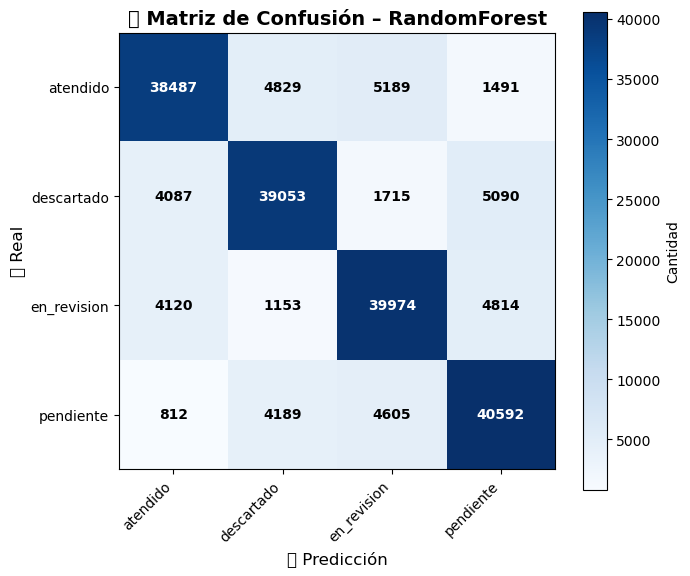

In [30]:
# ==============================
# 🔲 Matriz de Confusión
# ==============================

best_name = "RandomForest"  # cambiar si otro modelo fue mejor
best_model = fitted[best_name]
y_pred = preds[best_name]

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation='nearest', cmap="Blues")
plt.title(f"🔲 Matriz de Confusión – {best_name}", fontsize=14, fontweight="bold")
plt.colorbar(label="Cantidad")

# Etiquetas de ejes
plt.xlabel("🔮 Predicción", fontsize=12)
plt.ylabel("✅ Real", fontsize=12)

# Poner ticks con las clases
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

# Números dentro de cada celda
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j],
                 ha="center", va="center",
                 color="white" if cm[i,j] > cm.max()/2 else "black",
                 fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


## 10) Importancia de Features (RandomForest)

🌟 Top 20 características más importantes (incluyendo todas):


,feature,importance
0,latitud,0.507049
1,longitud,0.488767
16,descripcion_Se construye sin permisos visibles...,0.000167
29,descripcion_Vecinos reportan obra irregular en...,0.000163
17,descripcion_Se detectó daño en la banqueta de ...,0.000160
28,descripcion_Vecinos reportan actividad inusual...,0.000154
20,descripcion_Se observa material de construcció...,0.000154
15,descripcion_Reportan música muy fuerte a altas...,0.000153
23,descripcion_Se presentó un corte de energía en...,0.000147
14,descripcion_No hay servicio de agua desde hace...,0.000146


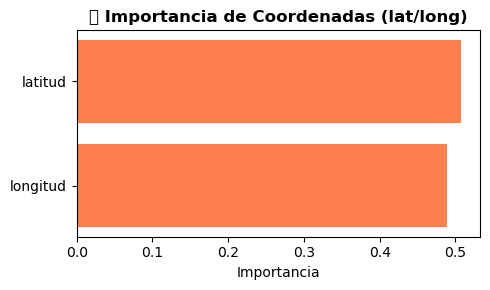

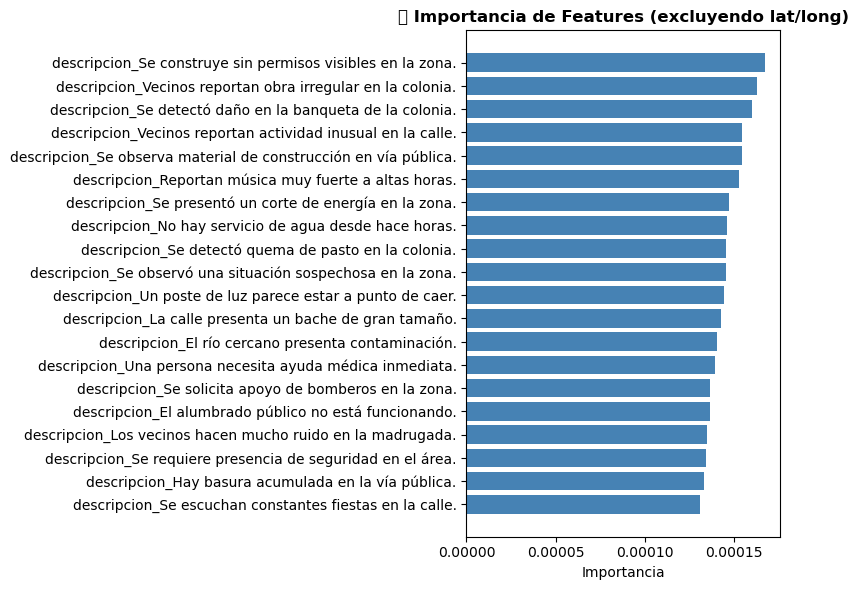

In [35]:
# ==============================
# 🌟 Importancia de Características (RandomForest)
# ==============================

prep = best_model.named_steps['prep']
ohe = prep.named_transformers_['categóricas'].named_steps['onehot'] \
      if 'categóricas' in prep.named_transformers_ else prep.named_transformers_['cat'].named_steps['onehot']

num_features = numeric_cols
cat_features = list(ohe.get_feature_names_out(categorical_cols)) if ohe is not None else []

feature_names = num_features + cat_features
rf_model = best_model.named_steps['clf']

# Calcular importancias
importances = rf_model.feature_importances_
fi_full = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

# Separar coordenadas y resto
fi_coords = fi_full[fi_full["feature"].isin(["latitud", "longitud"])]
fi_rest = fi_full[~fi_full["feature"].isin(["latitud", "longitud"])].head(20)

# Mostrar tabla top 20
print("\033[94m" + "🌟 Top 20 características más importantes (incluyendo todas):" + "\033[0m")
display(fi_full.head(20))

# --- Gráfica 1: Solo coordenadas ---
plt.figure(figsize=(5,3))
plt.barh(fi_coords["feature"][::-1], fi_coords["importance"][::-1], color="coral")
plt.title("🌍 Importancia de Coordenadas (lat/long)", fontsize=12, fontweight="bold")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

# --- Gráfica 2: Resto de features ---
plt.figure(figsize=(8,6))
plt.barh(fi_rest["feature"][::-1], fi_rest["importance"][::-1], color="steelblue")
plt.title("📊 Importancia de Features (excluyendo lat/long)", fontsize=12, fontweight="bold")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


## 11) Exportación del modelo

In [36]:
# ==============================
# 💾 Exportación del Modelo Entrenado
# ==============================

os.makedirs("models", exist_ok=True)
model_path = f"models/modelo_{best_name}.joblib"
joblib.dump(best_model, model_path)

print("\033[94m" + "💾 Guardando modelo..." + "\033[0m")
print("\033[92m✅ Modelo exportado correctamente\033[0m")
print(f"📂 Ruta: \033[96m{model_path}\033[0m")
print("\033[95m" + "-"*50 + "\033[0m")


💾 Guardando modelo...
✅ Modelo exportado correctamente
📂 Ruta: models/modelo_RandomForest.joblib
--------------------------------------------------
